# Label-transfer fidelity: confusion matrices and compositional concordance

**Reviewer comment.** *"Collapsing 88 scRNA-seq subtypes into 65 MERFISH-distinguishable labels via a 479-gene panel will blur fine T-cell distinctions on which several conclusions rest. Please provide a confusion matrix on matched-patient regions (C107, C110, C123, C164) and class-wise precision/recall for key subsets (Tcd8-CXCL13, -LAG3, -GZMK, mregDC, Myeloid-ISG)."*

### What this measures

The consolidation was not a hand-written mapping. The scRNA-seq reference was
downsampled to the 479 panel genes, corrected for donor, and subsets were
re-derived within each lineage. Every reference cell therefore carries both its
original atlas label and its re-derived label, and the relationship between them
is empirical. That relationship is the confusion matrix.

| quantity | column |
|---|---|
| original atlas subtype | `cl295v11SubFull` |
| lineage | `clTopLevel` |
| re-derived label | `cleaned_fine_types` |
| patient | `PID` |
| cell id | `orig.ident` |

### Lineages covered

Only B, myeloid, stromal and T/NK/ILC cells were fine typed. Epithelial, plasma
and mast cells carry no re-derived subtype, so they are excluded throughout: from
the Pelka to type_lvl2 map, from the confusion matrices, and from the
compositional comparison, where both modalities are renormalised within the
fine-typed lineages. This belongs in the response as a stated scope limit.

### Scope, stated plainly in the response

This quantifies the **consolidation** step, where the 479-gene constraint bites.
It does not quantify the weighted k-nearest-neighbour transfer onto MERFISH
cells, because MERFISH cells have no independent ground-truth annotation. That
step was assessed separately by marker and fold-change concordance in
Figure S1A to S1F.

### Caution carried from the ingestion step

`cleaned_fine_types` in these objects may not use the same vocabulary as the
MERFISH labels. Section 2 checks this explicitly and stops if the overlap is
poor, rather than silently comparing two different label sets.

## 0. Setup

In [1]:
rload_ok <- tryCatch({ source(here::here("src/rload.R")); TRUE },
                     error = function(e) { message("rload.R skipped"); FALSE })

library(here); library(data.table); library(tidyverse)
library(Seurat); library(ggplot2); library(cowplot); library(patchwork)
library(grid); library(scales)

## ggrepel is optional; the scatter falls back to plain labels without it
HAS_REPEL <- requireNamespace("ggrepel", quietly = TRUE)
if (!HAS_REPEL) message("ggrepel not installed: install.packages('ggrepel') for non-overlapping labels")

if (!exists("fig.size")) {
    fig.size <- function(height = 5, width = 7, res = 150)
        options(repr.plot.height = height, repr.plot.width = width, repr.plot.res = res)
}

BASE_PT <- 8
theme_lt <- function(base = BASE_PT) {
    b <- max(base, BASE_PT)
    cowplot::theme_cowplot(b) +
    theme(strip.background = element_blank(),
          strip.text    = element_text(size = b),
          axis.text     = element_text(size = BASE_PT),
          axis.title    = element_text(size = b),
          plot.title    = element_text(size = b + 2, face = "bold"),
          plot.subtitle = element_text(size = BASE_PT, colour = "grey25"),
          legend.title  = element_text(size = BASE_PT),
          legend.text   = element_text(size = BASE_PT))
}

## ---- paths ---------------------------------------------------------------
SCRNA_DIR     <- "../Cleaned scRNA references for cell typing"
TESSERA_DIR   <- "../Tessera tiles/Tessera processed results"
PATHOLOGY_CSV <- "../Pathology annotations/figure2/pathology_regions_postQC.csv"
XW_CSV        <- "../fig4_interface_analysis/fig4_threshold_free_outputs/cell_state_crosswalk.csv" 

outdir_lt <- "./label_transfer_fidelity_outputs"
dir.create(outdir_lt, showWarnings = FALSE, recursive = TRUE)

## ---- settled column names ------------------------------------------------
COL_OLD     <- "cl295v11SubFull"
COL_LINEAGE <- "clTopLevel"
COL_NEW     <- "cleaned_fine_types"
COL_PATIENT <- "PID"
COL_CELLID  <- "orig.ident"

MATCHED_PATIENTS <- c("C107", "C110", "C123", "C164")

## Only these lineages were fine typed. Epithelial, plasma and mast cells were
## not, so they carry no re-derived subtype and are excluded everywhere in this
## notebook: from the map, from the confusion matrices, and from the
## compositional comparison. Stated in the response as a scope limit.
FINE_TYPED_LINEAGES <- c("B", "Myeloid", "Strom", "TNKILC")
MANUAL_RELABEL   <- c("Tcd8-gdlike-PD1" = "Tcd8-CXCL13-LAG3")

## subsets the reviewer named, in the MERFISH vocabulary
## the reviewer's subsets, in manuscript naming. The data uses Pelka naming;
## the translation is set up in section 2.
KEY_SUBSETS <- c("Tcd8-CXCL13", "Tcd8-CXCL13-prolif", "Tcd8-CXCL13-LAG3",
                 "Tcd8-GZMK", "Myeloid-DCmreg", "Myeloid-ISGhigh", "Myeloid-ISGlow")

Loading packages


Warning message in check_dep_version(dep_pkg = "TMB"):
“package version mismatch: 
glmmTMB was built with TMB package version 1.9.19
Current TMB package version is 1.9.23
Please re-install glmmTMB from source or restore original ‘TMB’ package (see '?reinstalling' for more information)”


Saving output data and figures to: 
/home/helikarlab/mukta/crcmanuscript2025/outputs


Warning message in dir.create(outdir, showWarnings = TRUE):
“'/home/helikarlab/mukta/crcmanuscript2025/outputs' already exists”


Loading data files


rload.R skipped

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘cowplot’


The following object is masked from ‘package:patchwork’:

    align_plots


The following object is masked from ‘package:ggpubr’:

    get_legend


The following object is masked from ‘package:lubridate’:

    stamp




## 1. Load metadata

In [2]:
obj_files <- list.files(SCRNA_DIR, pattern = "\\.rds$", full.names = TRUE)
stopifnot(length(obj_files) > 0)

read_meta <- function(path) {
    obj <- readRDS(path)
    md  <- as.data.table(obj@meta.data, keep.rownames = "cell_barcode")
    md[, source_file := basename(path)]
    cat(sprintf("%-36s %7d cells\n", basename(path), ncol(obj)))
    rm(obj); gc(verbose = FALSE)
    md
}

meta_list <- lapply(obj_files, read_meta)
names(meta_list) <- basename(obj_files)

need <- c(COL_OLD, COL_LINEAGE, COL_NEW, COL_PATIENT, COL_CELLID)
scrna <- rbindlist(lapply(names(meta_list), function(f) {
    md <- meta_list[[f]]
    miss <- setdiff(need, names(md))
    if (length(miss)) stop("missing in ", f, ": ", paste(miss, collapse = ", "))
    out <- data.table(
        source_file = f,
        cell_id   = as.character(md[[COL_CELLID]]),
        patient   = as.character(md[[COL_PATIENT]]),
        lineage   = as.character(md[[COL_LINEAGE]]),
        old_label = as.character(md[[COL_OLD]]),
        new_label = as.character(md[[COL_NEW]])
    )
    if ("technology" %in% names(md)) out[, technology := as.character(md$technology)]
    out
}), fill = TRUE)

## keep scRNA cells only, if the objects mix modalities
if ("technology" %in% names(scrna)) {
    print(scrna[, .N, by = technology])
    scrna <- scrna[is.na(technology) | grepl("scRNA", technology, ignore.case = TRUE)]
}

## apply the same relabel used in the Figure 4 reanalysis
n_relab <- scrna[new_label %in% names(MANUAL_RELABEL), .N]
scrna[new_label %in% names(MANUAL_RELABEL), new_label := MANUAL_RELABEL[new_label]]
cat("\ncells relabelled:", n_relab, "\n")
cat("cells:", nrow(scrna), " lineages:", uniqueN(scrna$lineage),
    " old labels:", uniqueN(scrna$old_label),
    " new labels:", uniqueN(scrna$new_label), "\n\n")
print(scrna[, .(cells = .N, old = uniqueN(old_label), new = uniqueN(new_label)),
            by = lineage][order(-cells)])

unexpected <- setdiff(unique(scrna$lineage), FINE_TYPED_LINEAGES)
if (length(unexpected)) {
    warning("lineages present that were not expected to be fine typed: ",
            paste(unexpected, collapse = ", "))
}
scrna <- scrna[lineage %in% FINE_TYPED_LINEAGES]
cat("\ncells after restricting to fine-typed lineages:", nrow(scrna), "\n")

Bcells_fineTyping_all_genes.rds         9485 cells
Myeloid_fineTyping_all_genes.rds       26360 cells
Strom_fineTyping_all_genes.rds          6467 cells
TNKILC_fineTyping_all_genes.rds        57749 cells
   technology      N
       <char>  <int>
1:      scRNA 100061

cells relabelled: 0 
cells: 100061  lineages: 4  old labels: 69  new labels: 60 

   lineage cells   old   new
    <char> <int> <int> <int>
1:  TNKILC 57749    24    18
2: Myeloid 26360    10    19
3:       B  9485     3     5
4:   Strom  6467    32    18

cells after restricting to fine-typed lineages: 100061 


## 2. Vocabulary note

`cleaned_fine_types` holds **merged Pelka atlas labels** (`cTNI14 (CD8+ CXCL13+) & cTNI15 ...`),
not the manuscript short names (`Tcd8-CXCL13`). The rename to short names happens
later, during MERFISH fine typing, so the two label sets share no strings.

This does not affect the confusion matrices. Those compare `cl295v11SubFull`
against `cleaned_fine_types`, both of which are Pelka naming, so sections 3 to 5
run unchanged.

The short names are needed only to label the key subsets the reviewer named, and
for the compositional concordance in section 6. `KEY_SUBSET_MAP` below covers the
first. Section 6 is skipped unless `FULL_NAME_MAP` is supplied.

In [3]:
## Pelka merged label -> manuscript short name, for the subsets the reviewer named.
## CHECK the two ISG entries: the high/low split is assumed to follow the
## macrophage/monocyte split and should be confirmed before reporting.
KEY_SUBSET_MAP <- c(
    "cTNI14 (CD8+ CXCL13+) & cTNI15 (CD8+ CXCL13+ HSP+)"   = "Tcd8-CXCL13",
    "cTNI16 (CD8+ CXCL13+ prolif)"                          = "Tcd8-CXCL13-prolif",
    "cTNI18 (gd-like T PDCD1+) & cTNI19 (gd-like T prolif)" = "Tcd8-CXCL13-LAG3",
    "cTNI11 (CD8+GZMK+)"                                    = "Tcd8-GZMK",
    "cM09 (mregDC)"                                         = "Myeloid-DCmreg",
    "pM21 (ISGs)_macrophage"                                = "Myeloid-ISGhigh",
    "pM21 (ISGs)_monocytes"                                 = "Myeloid-ISGlow"
)

## Full Pelka -> short-name map. Leave empty to skip section 6.
FULL_NAME_MAP <- c()

miss <- setdiff(names(KEY_SUBSET_MAP), unique(scrna$new_label))
if (length(miss)) {
    warning("KEY_SUBSET_MAP keys not present in the data:\n  ",
            paste(miss, collapse = "\n  "))
} else {
    cat("all", length(KEY_SUBSET_MAP), "key-subset keys found\n")
}

## display name used in the precision / recall table
short_name <- function(x) ifelse(x %in% names(KEY_SUBSET_MAP), KEY_SUBSET_MAP[x], x)

## the key subsets, expressed in the Pelka naming actually used by the data
KEY_PELKA <- names(KEY_SUBSET_MAP)

print(scrna[new_label %in% KEY_PELKA,
            .(cells = .N, matched = sum(patient %in% MATCHED_PATIENTS)),
            by = .(new_label)][, short := short_name(new_label)][order(-cells)])

all 7 key-subset keys found
                                               new_label cells matched
                                                  <char> <int>   <int>
1:                                    cTNI11 (CD8+GZMK+)  5051     673
2:    cTNI14 (CD8+ CXCL13+) & cTNI15 (CD8+ CXCL13+ HSP+)  3291     560
3:                                pM21 (ISGs)_macrophage  2819     361
4: cTNI18 (gd-like T PDCD1+) & cTNI19 (gd-like T prolif)  2357     406
5:                          cTNI16 (CD8+ CXCL13+ prolif)  1972     337
6:                                         cM09 (mregDC)  1136     100
7:                                 pM21 (ISGs)_monocytes  1016     154
                short
               <char>
1:          Tcd8-GZMK
2:        Tcd8-CXCL13
3:    Myeloid-ISGhigh
4:   Tcd8-CXCL13-LAG3
5: Tcd8-CXCL13-prolif
6:     Myeloid-DCmreg
7:     Myeloid-ISGlow


## 2b. Build the Pelka to type_lvl2 map from the MERFISH objects

The per-sample MERFISH objects carry **both vocabularies on the same cells**:

- `knn_original_cell_states` is the Pelka naming, the same vocabulary as
  `cleaned_fine_types` in the scRNA objects
- `knn_renamed_cell_states` is the short-name version
- `cell` is in `tile_metadata`'s `cell_id` format, and `orig.ident` is the sample

The map is therefore built by joining these cells to `tile_metadata` and taking
`type_lvl2`, which is the authoritative final vocabulary, rather than trusting
`knn_renamed_cell_states`. That column is checked against `type_lvl2` separately,
so the assumption that the two agree is tested rather than assumed.

Several MERFISH samples were fine-typed and later discarded. Only samples present
in `tile_metadata` contribute, and the excluded ones are listed.

Results are cached to `pelka_to_type_lvl2.csv`. Delete that file to rebuild.

In [4]:
FINETYPE_DIR <- "../Labeled MERFISH data/Seurat objects"
MAP_CSV      <- file.path(outdir_lt, "pelka_to_type_lvl2.csv")
VERIFY_CSV   <- file.path(outdir_lt, "renamed_vs_type_lvl2.csv")

build_name_map <- function() {

    ft_files <- list.files(FINETYPE_DIR, pattern = "^annotated_.*\\.rds$",
                           full.names = TRUE)
    cat("annotated MERFISH objects found:", length(ft_files), "\n")
    if (!length(ft_files)) stop("no annotated_*.rds under ", FINETYPE_DIR)

    grab <- function(p) {
        o  <- readRDS(p)
        md <- as.data.table(o@meta.data)
        rm(o); gc(verbose = FALSE)
        needcol <- c("cell", "orig.ident", "knn_original_cell_states",
                     "knn_renamed_cell_states")
        miss <- setdiff(needcol, names(md))
        if (length(miss)) {
            warning(basename(p), " missing: ", paste(miss, collapse = ", "))
            return(NULL)
        }
        data.table(cell_id = as.character(md$cell),
                   sample  = as.character(md$orig.ident),
                   pelka   = as.character(md$knn_original_cell_states),
                   renamed = as.character(md$knn_renamed_cell_states),
                   file    = basename(p))
    }

    mf <- rbindlist(lapply(ft_files, grab), fill = TRUE)
    mf <- unique(mf[!is.na(cell_id)])
    cat("MERFISH cells read:", nrow(mf), " samples:", uniqueN(mf$sample), "\n")

    ## Mast cells carry an empty string in knn_renamed_cell_states and in
    ## knn_original_cell_states, because they were never fine typed. Label them
    ## as Mast rather than dropping them, so they are excluded by lineage later
    ## and not silently lost here or counted as a vocabulary disagreement.
    blank <- function(x) is.na(x) | trimws(x) == ""
    n_blank_ren <- sum(blank(mf$renamed))
    n_blank_pel <- sum(blank(mf$pelka))
    if (n_blank_ren || n_blank_pel) {
        cat("blank labels filled as Mast:", n_blank_ren, "renamed,",
            n_blank_pel, "original\n")
        mf[blank(renamed), renamed := "Mast"]
        mf[blank(pelka),   pelka   := "Mast"]
    }

    ## ---- restrict to samples retained in tile_metadata -------------------
    tm2 <- readr::read_rds(file.path(TESSERA_DIR, "tile_metadata_2025-07-22.rds"))
    setDT(tm2)
    keep_samples <- unique(as.character(tm2$SampleID))

    ## tile_metadata side: fill any blank type_lvl2 on Mast cells as well
    tm2[type_lvl1 == "Mast" & (is.na(type_lvl2) | trimws(as.character(type_lvl2)) == ""),
        type_lvl2 := "Mast"]

    ## fine-typed lineages only; epithelial, plasma and mast were not fine typed
    n_before <- nrow(tm2)
    tm2 <- tm2[as.character(type_lvl1) %in% FINE_TYPED_LINEAGES]
    cat("tile_metadata cells in fine-typed lineages:", nrow(tm2), "/", n_before,
        sprintf(" (%.1f%%)\n", 100 * nrow(tm2) / n_before))
    tm2 <- unique(tm2[, .(cell_id, type_lvl2 = as.character(type_lvl2))])

    seen    <- sort(unique(mf$sample))
    dropped <- setdiff(seen, keep_samples)
    cat("\nsamples fine-typed:", length(seen),
        " retained in tile_metadata:", length(intersect(seen, keep_samples)), "\n")
    if (length(dropped)) {
        cat("discarded, excluded from the map:\n")
        print(mf[sample %in% dropped, .(cells = .N), by = sample][order(-cells)])
        mf <- mf[sample %in% keep_samples]
        cat("cells after restriction:", nrow(mf), "\n")
    }
    missing_samples <- setdiff(keep_samples, seen)
    if (length(missing_samples)) {
        warning("samples in tile_metadata with no annotated object: ",
                paste(missing_samples, collapse = ", "))
    }

    ## ---- join to the authoritative vocabulary ----------------------------
    j <- merge(mf, tm2, by = "cell_id")
    cat("\njoined to type_lvl2:", nrow(j), "/", nrow(mf),
        sprintf(" (%.1f%%)\n", 100 * nrow(j) / max(nrow(mf), 1)))
    per_file <- merge(mf[, .(cells = .N), by = file],
                      j[, .(matched = .N), by = file], by = "file", all.x = TRUE)
    per_file[is.na(matched), matched := 0L][, pct := round(100 * matched / cells, 1)]
    print(per_file[order(pct)])
    ## Note: the match rate is well below 100 percent by design. Cells outside
    ## the fine-typed lineages, and cells never assigned to a Tessera tile, are
    ## absent from tm2 and drop out here.
    if (nrow(j) < 0.2 * nrow(mf)) {
        stop("almost nothing matched tile_metadata on `cell`. Check the id format.")
    }

    ## ---- verification: does knn_renamed_cell_states equal type_lvl2? -----
    ## sanity: every cell we filled as Mast should be Mast in type_lvl2 too
    filled_bad <- j[renamed == "Mast" & type_lvl2 != "Mast", .N]
    if (filled_bad > 0) {
        warning(filled_bad, " cells labelled Mast from a blank do not have ",
                "type_lvl2 == 'Mast'. Inspect before trusting the fill.")
        print(j[renamed == "Mast" & type_lvl2 != "Mast", .N, by = type_lvl2][order(-N)])
    } else {
        cat("all cells filled as Mast are Mast in type_lvl2\n")
    }

    ver <- j[, .N, by = .(renamed, type_lvl2)]
    ver[, total := sum(N), by = renamed]
    ver[, frac := N / total]
    agree <- j[renamed == type_lvl2, .N] / nrow(j)
    cat(sprintf("\nknn_renamed_cell_states equals type_lvl2 for %.2f%% of cells\n",
                100 * agree))
    disagree <- ver[renamed != type_lvl2][order(-N)]
    if (nrow(disagree)) {
        cat("where they differ:\n")
        print(disagree[, .(renamed, type_lvl2, n = N, frac = round(frac, 3))], nrow = 60)
    }
    fwrite(ver, VERIFY_CSV)

    ## ---- the map: plurality type_lvl2 for each Pelka label ---------------
    tab <- j[, .N, by = .(pelka, type_lvl2)]
    tab[, total := sum(N), by = pelka]
    out <- tab[order(pelka, -N), .SD[1], by = pelka][
        , .(pelka, type_lvl2, n = N, total, purity = round(N / total, 3))]
    fwrite(out, MAP_CSV)
    out
}

name_map_tab <- if (file.exists(MAP_CSV)) fread(MAP_CSV) else build_name_map()
print(name_map_tab[order(purity)], nrow = 100)

cat("\nentries with purity below 0.9, inspect these:\n")
print(name_map_tab[purity < 0.9])

                                                    pelka
                                                   <char>
 1:                                                  Mast
 2:                                      cB1 (B IGD+IgM+)
 3:                                       cB2 (B GC-like)
 4:                               cB2 (B GC-like)_GPR183+
 5:                           cB3 (B CD40+ GC-like)_CD40+
 6:                          cB3 (B CD40+ GC-like)_MK167+
 7:                              cM02 (Macrophage-like)_2
 8:                                            cM03 (DC1)
 9:                                            cM04 (DC2)
10:                                       cM05 (DC2 C1Q+)
11:                                            cM07 (pDC)
12:                                          cM08 (AS-DC)
13:                                         cM09 (mregDC)
14:                                    cM10 (Granulocyte)
15:                              cS01/S08 (Endo arterial)
16:           

In [5]:
## the map, in the form the rest of the notebook expects
FULL_NAME_MAP <- setNames(name_map_tab$type_lvl2, name_map_tab$pelka)

unmapped <- setdiff(unique(scrna$new_label), names(FULL_NAME_MAP))
cat("scRNA labels with no type_lvl2 mapping:", length(unmapped), "\n")
if (length(unmapped)) print(scrna[new_label %in% unmapped, .N, by = new_label][order(-N)])

scrna[, new_label_lvl2 := FULL_NAME_MAP[new_label]]
cat("cells mapped:", scrna[!is.na(new_label_lvl2), .N], "/", nrow(scrna), "\n")

## from here the analysis uses the final vocabulary; the Pelka label is kept
scrna[, new_label_pelka := new_label]
scrna[!is.na(new_label_lvl2), new_label := new_label_lvl2]

## apply the same relabel used in the Figure 4 reanalysis
n2 <- scrna[new_label %in% names(MANUAL_RELABEL), .N]
scrna[new_label %in% names(MANUAL_RELABEL), new_label := MANUAL_RELABEL[new_label]]
cat("relabelled after mapping:", n2, "\n\n")

KEY_PELKA  <- KEY_SUBSETS
short_name <- function(x) x

print(scrna[new_label %in% KEY_SUBSETS,
            .(cells = .N, matched = sum(patient %in% MATCHED_PATIENTS)),
            by = new_label][order(-cells)])

scRNA labels with no type_lvl2 mapping: 1 
           new_label     N
              <char> <int>
1: cM06 (DC IL22RA2)     4
cells mapped: 100057 / 100061 
relabelled after mapping: 2357 

            new_label cells matched
               <char> <int>   <int>
1:          Tcd8-GZMK  5051     673
2:        Tcd8-CXCL13  3291     560
3:     Myeloid-ISGlow  2819     361
4:   Tcd8-CXCL13-LAG3  2357     406
5: Tcd8-CXCL13-prolif  1972     337
6:     Myeloid-DCmreg  1136     100
7:    Myeloid-ISGhigh  1016     154


## 3. Did any cell change lineage?

Each object holds one lineage, so the re-derived label is lineage-constrained by
construction. This compares the original atlas lineage against the object it
came from. If nothing moves, cross-lineage confusion is structurally impossible
and that should be stated as a property of the method rather than shown as an
empty column.

In [6]:
obj_lineage <- scrna[, .N, by = .(source_file, lineage)][
    order(source_file, -N)][, .SD[1], by = source_file]
setnames(obj_lineage, "lineage", "object_lineage")
print(obj_lineage[, .(source_file, object_lineage, N)])

scrna <- merge(scrna, obj_lineage[, .(source_file, object_lineage)], by = "source_file")
scrna[, moved_lineage := lineage != object_lineage]

n_moved <- scrna[moved_lineage == TRUE, .N]
cat("\ncells whose atlas lineage differs from their object lineage:", n_moved,
    sprintf("(%.3f%%)\n", 100 * n_moved / nrow(scrna)))
if (n_moved > 0) {
    print(scrna[moved_lineage == TRUE, .N, by = .(object_lineage, lineage)][order(-N)])
    cat("\n=> cross-lineage columns are needed in the confusion matrices\n")
} else {
    cat("=> no cell changed lineage. The re-derivation is lineage-constrained,\n",
        "   so cross-lineage confusion is structurally impossible.\n", sep = "")
}

                        source_file object_lineage     N
                             <char>         <char> <int>
1:  Bcells_fineTyping_all_genes.rds              B  9485
2: Myeloid_fineTyping_all_genes.rds        Myeloid 26360
3:   Strom_fineTyping_all_genes.rds          Strom  6467
4:  TNKILC_fineTyping_all_genes.rds         TNKILC 57749

cells whose atlas lineage differs from their object lineage: 0 (0.000%)
=> no cell changed lineage. The re-derivation is lineage-constrained,
   so cross-lineage confusion is structurally impossible.


## 4. Confusion matrices, one per lineage

Rows are original atlas subtypes, columns are re-derived labels, and cells are
row-normalised so each row sums to 100 percent. A row concentrated in one column
means that subtype survived the consolidation intact; a row spread across several
columns is a subtype the 479-gene panel could not hold together.

Drawn both for the four matched patients, which is what the comment asks for,
and for all patients, which is better powered for the rare classes.

In [7]:
conf_counts <- function(dat) dat[, .N, by = .(lineage, old_label, new_label)]

## row-normalised matrix for one lineage: rows are original atlas subtypes,
## columns are re-derived labels, values are percent of the row
conf_matrix <- function(cnt, .lineage, min_cells = 10) {
    d <- cnt[lineage == .lineage]
    if (!nrow(d)) return(NULL)
    d[, row_total := sum(N), by = old_label]
    d <- d[row_total >= min_cells]
    if (!nrow(d)) return(NULL)
    d[, pct := 100 * N / row_total]

    m <- dcast(d, old_label ~ new_label, value.var = "pct", fill = 0)
    rn <- m$old_label
    m <- as.matrix(m[, -1]); rownames(m) <- rn

    ## row counts for the annotation
    n_row <- d[, .(n = row_total[1]), by = old_label][match(rn, old_label), n]
    attr(m, "n_row") <- n_row
    m
}

## ---- drawing constants ---------------------------------------------------
PAGE_W <- 7.5      # letter portrait, half-inch margins
PAGE_H <- 10
BAR_COLS      <- 4     # width of the n-cells bar, in heatmap-column units
LABEL_MIN_PCT <- 10    # only label cells carrying a real share of the row
LABEL_PT      <- 5.5
TILE_LINE     <- 0.12  # gridline between cells
HEAT_COLS     <- c("#FFFFFF", "#5BA3CF", "#08306B")
CELL_H_IN     <- 0.16  # nominal row height, used only for single-panel files
PANEL_FIXED_H <- 2.2   # title, rotated column names and margins, in inches

## wrap long panel headings rather than letting them run off the page
wrap_title <- function(x, width = 60)
    paste(strwrap(x, width = width), collapse = "\n")

## Clustering is done here rather than by the plotting layer, so the order is
## fixed in the factor levels and is identical in the heatmap and in its
## companion bar. Degenerate matrices (fewer than three rows) keep input order.
clust_order <- function(m, margin = 1L) {
    x <- if (margin == 1L) m else t(m)
    labs <- rownames(x)
    if (is.null(labs) || nrow(x) < 3) return(labs)
    hc <- tryCatch(stats::hclust(stats::dist(x, method = "euclidean")),
                   error = function(e) NULL)
    if (is.null(hc)) labs else labs[hc$order]
}

## ---- panel ordering ------------------------------------------------------
## Clustering is the default for every panel. T/NK/ILC is the exception: it is
## the one lineage where the consolidation is a merge (24 atlas subtypes into 16
## re-derived labels) and the question the reviewer asks is which subtypes stay
## together, so its rows and columns are ordered into a block staircase instead.
## There is no true diagonal to recover in a non-square merge; what these two
## functions build is the nearest honest thing to one.

## every row's plurality destination and the share of the row it takes
row_dest <- function(m) {
    j <- max.col(m, ties.method = "first")
    data.table(old_label = rownames(m),
               dest      = colnames(m)[j],
               strength  = m[cbind(seq_len(nrow(m)), j)])
}

## Column order is supplied by hand, because it is a biological ordering rather
## than something the data can settle. Rows then follow from it: grouped by the
## column that takes most of them, strongest first inside a group. Columns that
## are nobody's plurality destination would otherwise punch a hole in the
## staircase, so each is parked beside the group of the row contributing most of
## its cells. Rows whose plurality is weaker than weak_below are collected at the
## foot of the panel rather than being given a step they do not earn.
staircase_order <- function(m, col_order = NULL, weak_below = NULL) {
    rd   <- row_dest(m)
    cols <- colnames(m)

    unknown <- setdiff(col_order, cols)
    if (length(unknown))
        warning("col_order names not in the matrix: ", paste(unknown, collapse = ", "))

    ord     <- c(intersect(col_order, cols),
                 setdiff(unique(rd$dest[order(-rd$strength)]), col_order))
    orphans <- setdiff(cols, ord)
    for (o in orphans) {
        src_row <- rownames(m)[which.max(m[, o])]
        at      <- match(rd$dest[rd$old_label == src_row], ord)
        ord     <- append(ord, o, after = if (is.na(at)) length(ord) else at)
    }
    stopifnot(setequal(ord, cols), !anyDuplicated(ord))

    rd[, dest_i := as.numeric(match(dest, ord))]
    rd[, weak := FALSE]
    if (!is.null(weak_below)) rd[strength < weak_below, `:=`(weak = TRUE, dest_i = Inf)]
    setorder(rd, dest_i, -strength)

    list(rows = rd$old_label, cols = ord, table = rd[])
}

## matrix -> long table with ordered factor levels, which is what ggplot wants
## row_ord and col_ord override the clustering when supplied. They are
## intersected with the matrix, so one order derived from the all-patient matrix
## can be reused on the matched-patient matrix, where some labels are missing.
conf_long <- function(m, row_ord = NULL, col_ord = NULL) {
    if (is.null(m)) return(NULL)
    row_ord <- if (is.null(row_ord)) clust_order(m, 1L) else intersect(row_ord, rownames(m))
    col_ord <- if (is.null(col_ord)) clust_order(m, 2L) else intersect(col_ord, colnames(m))
    stopifnot(setequal(row_ord, rownames(m)), setequal(col_ord, colnames(m)))
    n_row <- attr(m, "n_row"); names(n_row) <- rownames(m)
    d <- melt(as.data.table(m, keep.rownames = "old_label"),
              id.vars = "old_label", variable.name = "new_label",
              value.name = "pct", variable.factor = FALSE)
    ## rev() so the first row of the order sits at the top of the panel
    d[, old_label := factor(old_label, levels = rev(row_ord))]
    d[, new_label := factor(new_label, levels = col_ord)]
    d[, n_cells := n_row[as.character(old_label)]]
    d[]
}

theme_conf <- function() {
    theme_lt() +
    theme(axis.line = element_blank(), axis.ticks = element_blank(),
          axis.text.x = element_text(size = 6.5, angle = 45, hjust = 1, vjust = 1),
          axis.text.y = element_text(size = 6.5),
          plot.title  = element_text(size = 8.5, face = "bold", hjust = 0),
          plot.margin = margin(2, 2, 2, 2),
          panel.border = element_rect(colour = "grey70", fill = NA, linewidth = 0.3),
          legend.title = element_text(size = 7), legend.text = element_text(size = 6),
          legend.key.height = unit(0.32, "in"), legend.key.width = unit(0.11, "in"))
}

## one lineage, as a ggplot. The fill scale is fixed at 0 to 100 in every panel,
## so one legend serves the whole page and a colour means the same thing
## everywhere.
conf_gg <- function(dl, .lineage, title_suffix) {
    ggplot(dl, aes(new_label, old_label, fill = pct)) +
        geom_tile(colour = "grey85", linewidth = TILE_LINE) +
        geom_text(data = dl[pct >= LABEL_MIN_PCT],
                  aes(label = sprintf("%.0f", pct), colour = pct >= 55),
                  size = LABEL_PT / .pt, show.legend = FALSE) +
        scale_colour_manual(values = c(`FALSE` = "grey15", `TRUE` = "white"),
                            guide = "none") +
        scale_fill_gradientn(colours = HEAT_COLS, values = c(0, 0.5, 1),
                             limits = c(0, 100), breaks = c(0, 50, 100),
                             name = "% of row") +
        scale_x_discrete(expand = c(0, 0)) +
        scale_y_discrete(expand = c(0, 0), drop = FALSE) +
        labs(title = wrap_title(paste0(.lineage, ", ", title_suffix)),
             x = NULL, y = NULL) +
        theme_conf()
}

## the n-cells annotation, as its own plot. It shares the heatmap's y factor,
## so patchwork aligns the bars with the rows.
nrow_bar <- function(dl) {
    d <- unique(dl[, .(old_label, n_cells)])
    ggplot(d, aes(n_cells, old_label)) +
        geom_col(fill = "grey60", width = 0.75) +
        scale_x_continuous(expand = expansion(mult = c(0, 0.05)),
                           breaks = scales::breaks_pretty(2),
                           labels = scales::label_number(big.mark = ",")) +
        scale_y_discrete(expand = c(0, 0), drop = FALSE) +
        labs(title = "n cells", x = NULL, y = NULL) +
        theme_lt() +
        theme(axis.text.y = element_blank(), axis.ticks.y = element_blank(),
              axis.line.y = element_blank(),
              axis.text.x = element_text(size = 5.5),
              plot.title  = element_text(size = 7, face = "plain", colour = "grey25"),
              plot.margin = margin(2, 2, 2, 2))
}

cnt_all     <- conf_counts(scrna)
cnt_matched <- conf_counts(scrna[patient %in% MATCHED_PATIENTS])
fwrite(cnt_all,     file.path(outdir_lt, "confusion_counts_all_patients.csv"))
fwrite(cnt_matched, file.path(outdir_lt, "confusion_counts_matched_patients.csv"))

lineages <- sort(unique(scrna$lineage))
mats_matched <- setNames(lapply(lineages, function(lg) conf_matrix(cnt_matched, lg)), lineages)
mats_all     <- setNames(lapply(lineages, function(lg) conf_matrix(cnt_all,     lg)), lineages)

print(data.table(lineage = lineages,
                 rows_matched = sapply(mats_matched, function(m) if (is.null(m)) 0L else nrow(m)),
                 cols_matched = sapply(mats_matched, function(m) if (is.null(m)) 0L else ncol(m)),
                 rows_all     = sapply(mats_all,     function(m) if (is.null(m)) 0L else nrow(m)),
                 cols_all     = sapply(mats_all,     function(m) if (is.null(m)) 0L else ncol(m))))

   lineage rows_matched cols_matched rows_all cols_all
    <char>        <int>        <int>    <int>    <int>
1:       B            3            5        3        5
2: Myeloid            8           17        9       17
3:   Strom            4            4       31       17
4:  TNKILC           24           16       24       16


### 4a. All four lineages on one page

The panels are ggplot heatmaps, arranged by `patchwork` into a single flat grid:
one grid column per re-derived label, four more for the count bar, and one grid
row per original subtype. Grid rows and columns are equal, so **a cell is the
same size in every panel**, and a lineage with few labels occupies fewer columns
rather than being stretched across the page. Titles and axis text take their own
space on top of the panels, so no fixed overhead has to be budgeted by hand.

The fill scale is fixed at 0 to 100 percent in every panel and the guide is
collected once for the page, so one legend serves all four.

Rows and columns are clustered, so subtypes that behave alike sit together and
the near-diagonal structure is visible without the labels having to be read in
order. **T/NK/ILC is the exception**: its rows and columns are ordered into a
block staircase instead, built in section 4b. Either way the order is fixed when
the long table is built and is carried in the factor levels, so a heatmap and its
count bar cannot fall out of step.

In [8]:
## Assemble the lineages onto one page with patchwork.
##
## The layout is a single flat grid, not nested patchworks, so every panel is
## placed by area() into a shared grid: one grid column per heatmap column, plus
## BAR_COLS columns for the bar, and one grid row per matrix row. Grid rows and
## columns are equal null units, so a cell is the same size in every panel, and
## a narrow lineage occupies fewer columns rather than being stretched across
## the page. Titles and axis text take their natural size on top of that, which
## is why no fixed overhead has to be budgeted by hand.
## `orders` is a named list, one entry per lineage that needs an explicit order,
## each a list(rows = , cols = ). A lineage with no entry keeps the clustering.
assemble_page_gg <- function(mats, title_suffix, fname = NULL,
                             page_w = PAGE_W, page_h = PAGE_H, show_bar = TRUE,
                             orders = list()) {

    keep <- names(mats)[!vapply(mats, is.null, logical(1))]
    if (!length(keep)) { warning("nothing to draw"); return(invisible(NULL)) }

    longs <- lapply(keep, function(lg)
        conf_long(mats[[lg]], orders[[lg]]$rows, orders[[lg]]$cols))
    names(longs) <- keep
    ncols <- vapply(keep, function(lg) ncol(mats[[lg]]), integer(1))
    nrows <- vapply(keep, function(lg) nrow(mats[[lg]]), integer(1))
    max_ncol <- max(ncols)
    bar_cols <- if (show_bar) BAR_COLS else 0L

    plots <- list(); area_list <- list(); top <- 0L
    for (i in seq_along(keep)) {
        plots <- c(plots, list(conf_gg(longs[[i]], keep[i], title_suffix)))
        area_list <- c(area_list, list(patchwork::area(
            t = top + 1L, l = 1L, b = top + nrows[i], r = ncols[i])))
        if (show_bar) {
            plots <- c(plots, list(nrow_bar(longs[[i]])))
            area_list <- c(area_list, list(patchwork::area(
                t = top + 1L, l = max_ncol + 1L,
                b = top + nrows[i], r = max_ncol + bar_cols)))
        }
        top <- top + nrows[i]
    }

    pg <- patchwork::wrap_plots(plots, design = do.call(c, area_list)) +
          patchwork::plot_layout(guides = "collect") &
          theme(legend.position = "right")

    cat(sprintf("panels: %s   rows %d   max cols %d   page %.1f x %.1f in\n",
                paste(keep, collapse = ", "), sum(nrows), max_ncol, page_w, page_h))
    if (!is.null(fname)) {
        ggplot2::ggsave(file.path(outdir_lt, fname), pg,
                        width = page_w, height = page_h, units = "in",
                        dpi = 400, bg = "white", limitsize = FALSE)
        cat("written:", fname, "\n")
    }
    pg
}

### 4b. The staircase order for the T/NK/ILC panel

The other three lineages keep the clustering. T/NK/ILC gets an explicit order,
for two reasons: it is the compartment the comment is about, and it is the one
where the consolidation merges many atlas subtypes into fewer labels, so grouping
rows by where they land is a statement about the data rather than decoration.

`COL_ORDER_TNKILC` is the one hand-made choice here: CD4 states, then Treg and
the follicular/CXCL13 CD4 labels, then the CD8 block, then gd-like and PLZF,
then NK, then ILC. Rows follow from it mechanically. Subtypes whose largest
destination takes less than `WEAK_BELOW` percent of them are collected at the
foot of the panel instead of being given a step, which is where cTNI14, cTNI17
and cTNI18 are expected to sit.

The order is derived **once, from the all-patient matrix**, and reused for the
matched-patient page, so a subtype occupies the same position in both figures.
`ord_tnkilc$table` is written out, so the order is auditable rather than being a
choice buried in a chart.

Ordering is presentational: no value in the matrix changes, and the printed
percentages are what carry the strength of each block. A pale step is still a
pale step.

In [9]:
## hand-made column order: CD4, Treg/TFH/CXCL13 CD4, CD8, gd-like and PLZF, NK, ILC
COL_ORDER_TNKILC <- c(
    "Tcd4-IL7R", "Tcd4-Treg", "Tcd4-Treg-prolif", "Tcd4-TFH", "Tcd4-CXCL13",
    "Tcd8-GZMK", "Tcd8-HOBIT", "Tcd8-CXCL13", "Tcd8-CXCL13-prolif",
    "Tcd8-CXCL13-LAG3", "Tcd8-gdlike", "Tplzf-gdlike", "Tplzf-gdlike-prolif",
    "NK-CD16", "NK-XCL1", "ILC3")

WEAK_BELOW <- 30   # plurality share under which a row is sent to the foot

stopifnot(!is.null(mats_all[["TNKILC"]]))
ord_tnkilc <- staircase_order(mats_all[["TNKILC"]],
                              col_order  = COL_ORDER_TNKILC,
                              weak_below = WEAK_BELOW)

## every lineage absent from this list keeps the clustering
panel_orders <- list(TNKILC = ord_tnkilc[c("rows", "cols")])

fwrite(ord_tnkilc$table, file.path(outdir_lt, "tnkilc_panel_order.csv"))
cat("T/NK/ILC rows in a block:", sum(!ord_tnkilc$table$weak),
    " at the foot:", sum(ord_tnkilc$table$weak),
    " (plurality below", WEAK_BELOW, "percent)\n")
print(ord_tnkilc$table[, .(old_label, dest, strength = round(strength, 1), weak)])

T/NK/ILC rows in a block: 18  at the foot: 6  (plurality below 30 percent)
                       old_label                dest strength   weak
                          <char>              <char>    <num> <lgcl>
 1:     cTNI02 (CD4+ IL7R+SELL+)           Tcd4-IL7R     83.2  FALSE
 2:     cTNI04 (CD4+ IL7R+CCL5+)           Tcd4-IL7R     77.7  FALSE
 3:      cTNI03 (CD4+ IL7R+HSP+)           Tcd4-IL7R     69.9  FALSE
 4:          cTNI01 (CD4+ IL7R+)           Tcd4-IL7R     53.1  FALSE
 5:           cTNI08 (CD4+ Treg)           Tcd4-Treg     76.5  FALSE
 6:    cTNI09 (CD4+ Treg prolif)    Tcd4-Treg-prolif     52.1  FALSE
 7:            cTNI06 (CD4+ TFH)            Tcd4-TFH     34.8  FALSE
 8:        cTNI07 (CD4+ CXCL13+)         Tcd4-CXCL13     76.2  FALSE
 9:           cTNI11 (CD8+GZMK+)           Tcd8-GZMK     68.8  FALSE
10:          cTNI10 (CD8+ IL7R+)          Tcd8-HOBIT     60.6  FALSE
11: cTNI16 (CD8+ CXCL13+ prolif)  Tcd8-CXCL13-prolif     57.4  FALSE
12:             cTNI20 (PLZF

### 4c. The assembled page

panels: B, Myeloid, Strom, TNKILC   rows 39   max cols 17   page 7.5 x 10.0 in
written: confusion_page_matched.png 


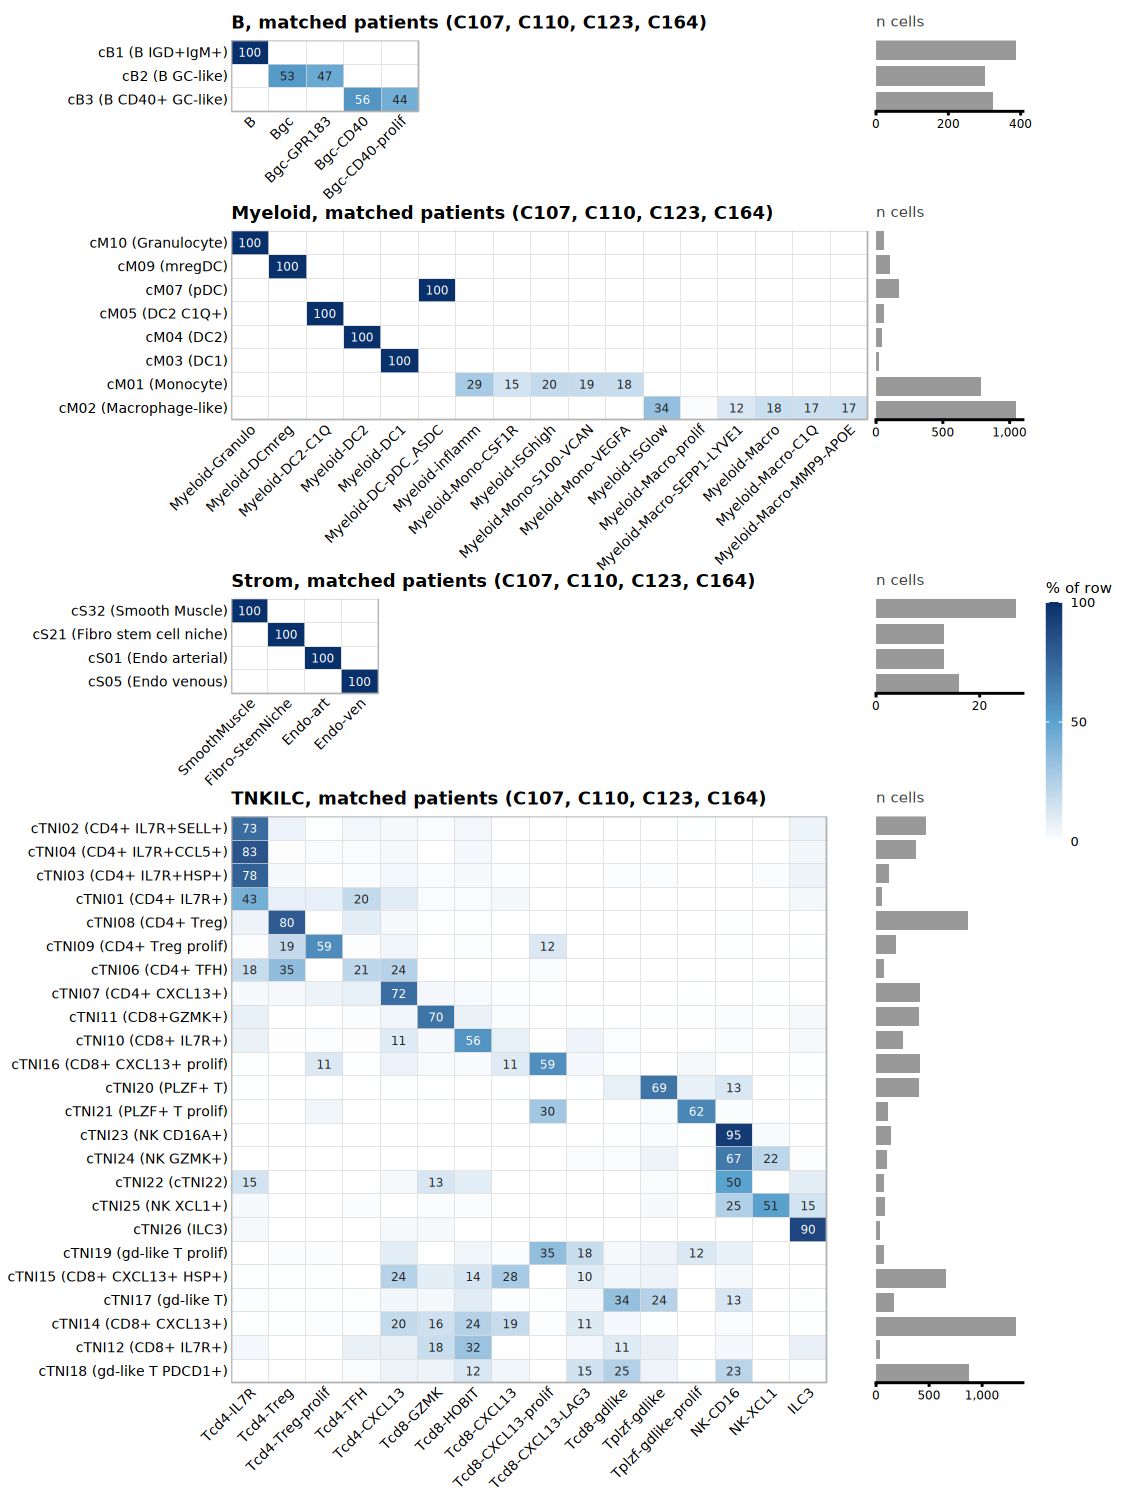

In [10]:
fig.size(height = 10, width = 7.5, res = 150)
p_matched <- assemble_page_gg(mats_matched,
                              "matched patients (C107, C110, C123, C164)",
                              "confusion_page_matched.png",
                              orders = panel_orders)
p_matched

panels: B, Myeloid, Strom, TNKILC   rows 67   max cols 17   page 7.5 x 10.0 in
written: confusion_page_all.png 
panels: B   rows 3   max cols 5   page 7.5 x 2.7 in
written: confusion_all_B.png 
panels: Myeloid   rows 9   max cols 17   page 7.5 x 3.6 in
written: confusion_all_Myeloid.png 
panels: Strom   rows 31   max cols 17   page 7.5 x 7.2 in
written: confusion_all_Strom.png 
panels: TNKILC   rows 24   max cols 16   page 7.5 x 6.0 in
written: confusion_all_TNKILC.png 
individual panels written


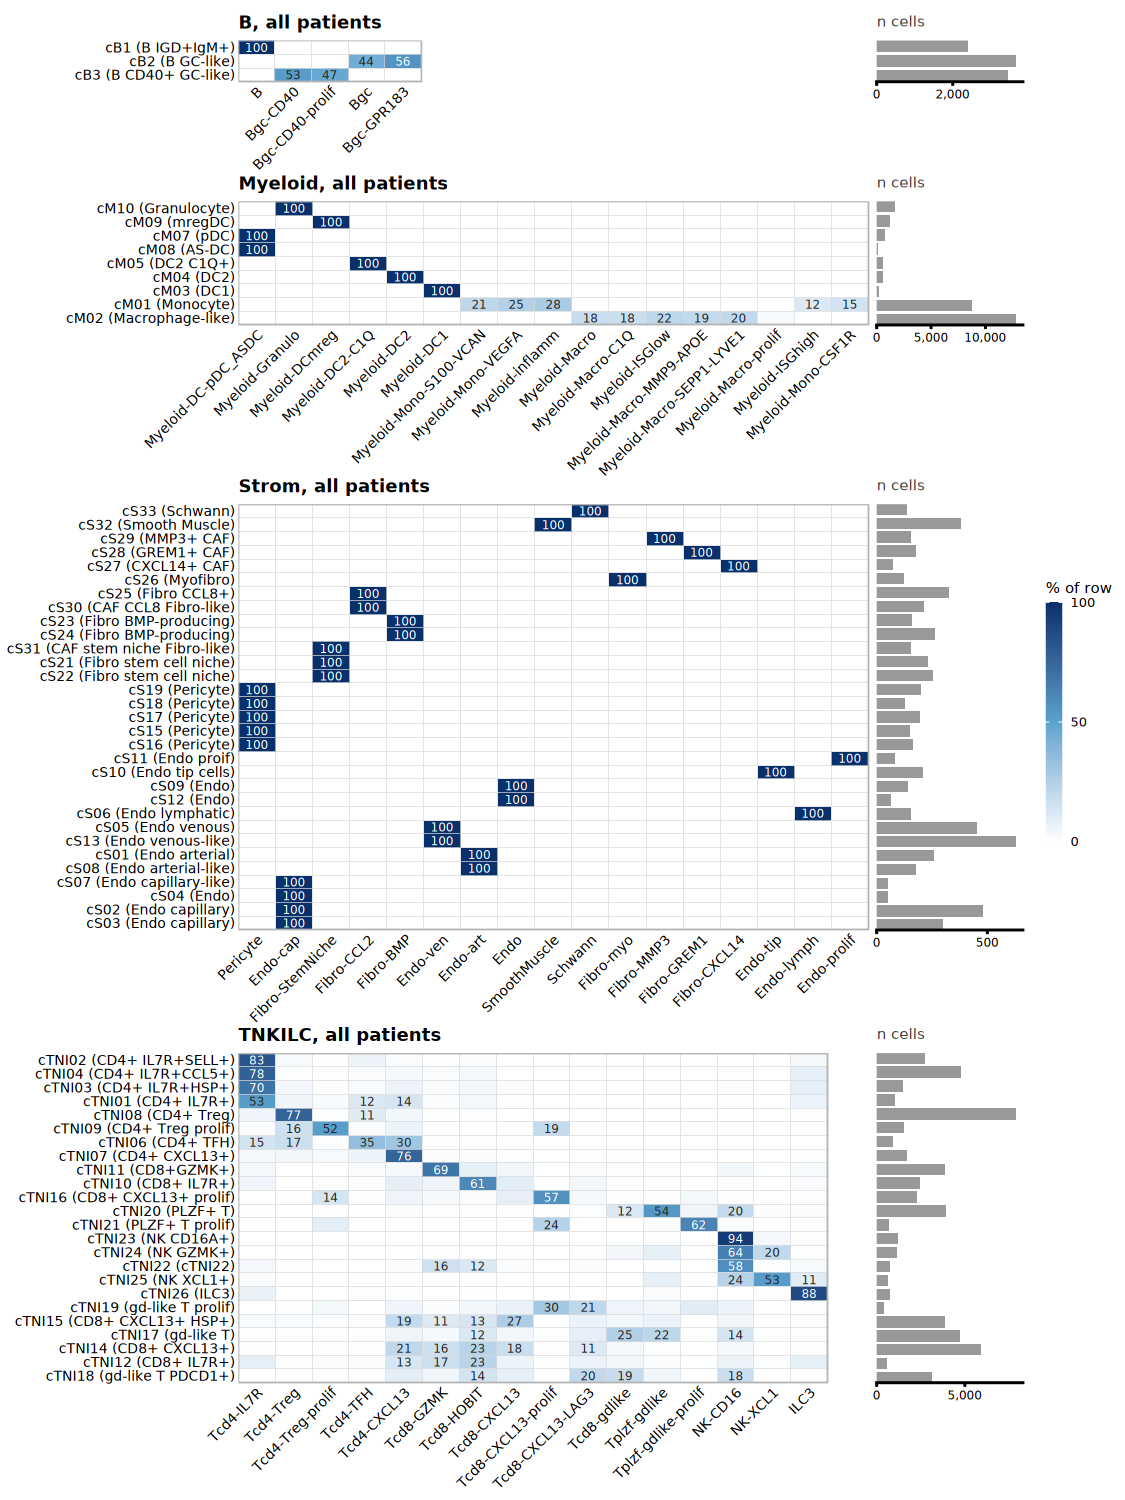

In [11]:
fig.size(height = 10, width = 7.5, res = 150)
p_all <- assemble_page_gg(mats_all, "all patients", "confusion_page_all.png",
                          orders = panel_orders)
p_all

## individual panels too, each on a page sized to its own row count
for (lg in names(mats_all)) {
    m <- mats_all[[lg]]
    if (is.null(m)) next
    assemble_page_gg(mats_all[lg], "all patients",
                     sprintf("confusion_all_%s.png", lg),
                     page_w = PAGE_W,
                     page_h = nrow(m) * CELL_H_IN + PANEL_FIXED_H,
                     orders = panel_orders)
}
cat("individual panels written\n")

## 5. Class-wise precision and recall

There is no ground truth here, so these are measures of **agreement with the
original annotation**, not accuracy.

The diagonal has to be defined, because the two vocabularies share no names. For
each original subtype we take its **plurality destination**, the re-derived label
that most of its cells received. A cell is then counted as agreeing if it landed
in its subtype's plurality destination.

For a re-derived label k, writing D(k) for the set of original subtypes whose
plurality destination is k:

- precision = cells with new label k whose original subtype is in D(k), over all cells with new label k
- recall = the same numerator, over all cells whose original subtype is in D(k)

Precision asks how pure the re-derived class is. Recall asks how much of the
original population it retained. Where several original subtypes map to one
re-derived label the merge is intended: precision rises, and recall becomes the
cell-weighted mean of those subtypes' retention. The mapping table is exported
so this is auditable.

In [12]:
prec_recall <- function(dat) {
    cnt <- dat[, .N, by = .(old_label, new_label)]
    ## plurality destination of each original subtype
    dest <- cnt[order(old_label, -N), .SD[1], by = old_label][, .(old_label, dest = new_label)]
    d <- merge(dat, dest, by = "old_label")
    d[, agrees := new_label == dest]

    res <- merge(
        d[, .(n_called = .N, tp = sum(agrees)), by = .(class = new_label)],
        d[, .(n_true = .N),                     by = .(class = dest)],
        by = "class", all = TRUE)
    res[is.na(n_called), n_called := 0L][is.na(n_true), n_true := 0L][is.na(tp), tp := 0L]
    res[, `:=`(precision = fifelse(n_called > 0, tp / n_called, NA_real_),
               recall    = fifelse(n_true   > 0, tp / n_true,   NA_real_))]
    res[, f1 := 2 * precision * recall / (precision + recall)]
    res[, n_sources := uniqueN(dest[dest == class]), by = class]
    list(res = res[order(-n_true)], dest = dest)
}

pr_all     <- prec_recall(scrna)
pr_matched <- prec_recall(scrna[patient %in% MATCHED_PATIENTS])

fwrite(pr_all$dest, file.path(outdir_lt, "plurality_destination_map.csv"))
fwrite(pr_all$res,     file.path(outdir_lt, "precision_recall_all_patients.csv"))
fwrite(pr_matched$res, file.path(outdir_lt, "precision_recall_matched_patients.csv"))

fmt <- function(x) x[, .(class, n_true, n_called,
                         precision = round(precision, 3),
                         recall = round(recall, 3),
                         f1 = round(f1, 3))]

fmt2 <- function(x) {
    y <- fmt(x[class %in% KEY_PELKA])
    y[, short := short_name(class)]
    setcolorder(y, c("short", "class"))[]
}
cat("==== KEY SUBSETS, matched patients ====\n")
print(fmt2(pr_matched$res))
cat("\n==== KEY SUBSETS, all patients ====\n")
print(fmt2(pr_all$res))
cat("\nNOTE: report n alongside every metric. Classes with fewer than 100 cells\n",
    "in the matched set give unstable precision and recall.\n", sep = "")

## A class with n_true == 0 is never any subtype's plurality destination. That
## is a real result, not a failure, but printed as precision 0 and recall NA it
## reads like a bug. Name those classes explicitly.
orphans <- rbind(
    pr_all$res[n_true == 0 & n_called > 0][, set := "all patients"],
    pr_matched$res[n_true == 0 & n_called > 0][, set := "matched patients"]
)
if (nrow(orphans)) {
    cat("\nClasses that are no subtype's plurality destination.\n",
        "Cells are assigned to them, but every contributing subtype sends most\n",
        "of its cells elsewhere. Recall is undefined; report as such rather than\n",
        "as zero.\n", sep = "")
    print(orphans[, .(set, class, n_called, n_true)])

    ## where those cells actually came from
    for (cl in unique(orphans$class)) {
        src <- cnt_all[new_label == cl, .(n = sum(N)), by = old_label][order(-n)]
        src[, pct_of_class := round(100 * n / sum(n), 1)]
        cat("\nsources of", cl, ":\n"); print(head(src, 8))
    }
}

==== KEY SUBSETS, matched patients ====
                short              class n_true n_called precision recall    f1
               <char>             <char>  <int>    <int>     <num>  <num> <num>
1:     Myeloid-ISGlow     Myeloid-ISGlow   1047      361     1.000  0.345 0.513
2:        Tcd8-CXCL13        Tcd8-CXCL13    657      560     0.332  0.283 0.306
3: Tcd8-CXCL13-prolif Tcd8-CXCL13-prolif    476      337     0.780  0.553 0.647
4:          Tcd8-GZMK          Tcd8-GZMK    404      673     0.419  0.698 0.524
5:     Myeloid-DCmreg     Myeloid-DCmreg    100      100     1.000  1.000 1.000
6:    Myeloid-ISGhigh    Myeloid-ISGhigh      0      154     0.000     NA    NA
7:   Tcd8-CXCL13-LAG3   Tcd8-CXCL13-LAG3      0      406     0.000     NA    NA

==== KEY SUBSETS, all patients ====
                short              class n_true n_called precision recall    f1
               <char>             <char>  <int>    <int>     <num>  <num> <num>
1:     Myeloid-ISGlow     Myeloid-ISGlow  1

In [13]:
## Where each original subtype ended up, for the key classes.
## row_total is computed over ALL destinations BEFORE filtering, so pct is the
## percentage of that subtype, not the percentage of the filtered subset.
key_dest <- merge(cnt_all, pr_all$dest, by = "old_label")
key_dest[, row_total := sum(N), by = old_label]
key_dest[, pct := round(100 * N / row_total, 1)]
key_dest <- key_dest[dest %in% KEY_SUBSETS | new_label %in% KEY_SUBSETS]

print(key_dest[order(dest, old_label, -pct),
               .(old_label, new_label, N, row_total, pct, plurality_dest = dest)][pct >= 5],
      nrow = 120)
fwrite(key_dest, file.path(outdir_lt, "key_subset_destinations.csv"))

                       old_label                 new_label     N row_total
                          <char>                    <char> <int>     <int>
 1:                cM09 (mregDC)            Myeloid-DCmreg  1136      1136
 2:       cM02 (Macrophage-like)            Myeloid-ISGlow  2819     12801
 3:       cM02 (Macrophage-like) Myeloid-Macro-SEPP1-LYVE1  2603     12801
 4:       cM02 (Macrophage-like)   Myeloid-Macro-MMP9-APOE  2494     12801
 5:       cM02 (Macrophage-like)             Myeloid-Macro  2303     12801
 6:       cM02 (Macrophage-like)         Myeloid-Macro-C1Q  2255     12801
 7:              cM01 (Monocyte)           Myeloid-ISGhigh  1016      8755
 8:              cTNI22 (cTNI22)                 Tcd8-GZMK   112       712
 9:    cTNI09 (CD4+ Treg prolif)        Tcd8-CXCL13-prolif   290      1500
10:   cTNI15 (CD8+ CXCL13+ HSP+)               Tcd8-CXCL13  1041      3868
11:   cTNI15 (CD8+ CXCL13+ HSP+)               Tcd4-CXCL13   747      3868
12:   cTNI15 (CD8+ CXCL13

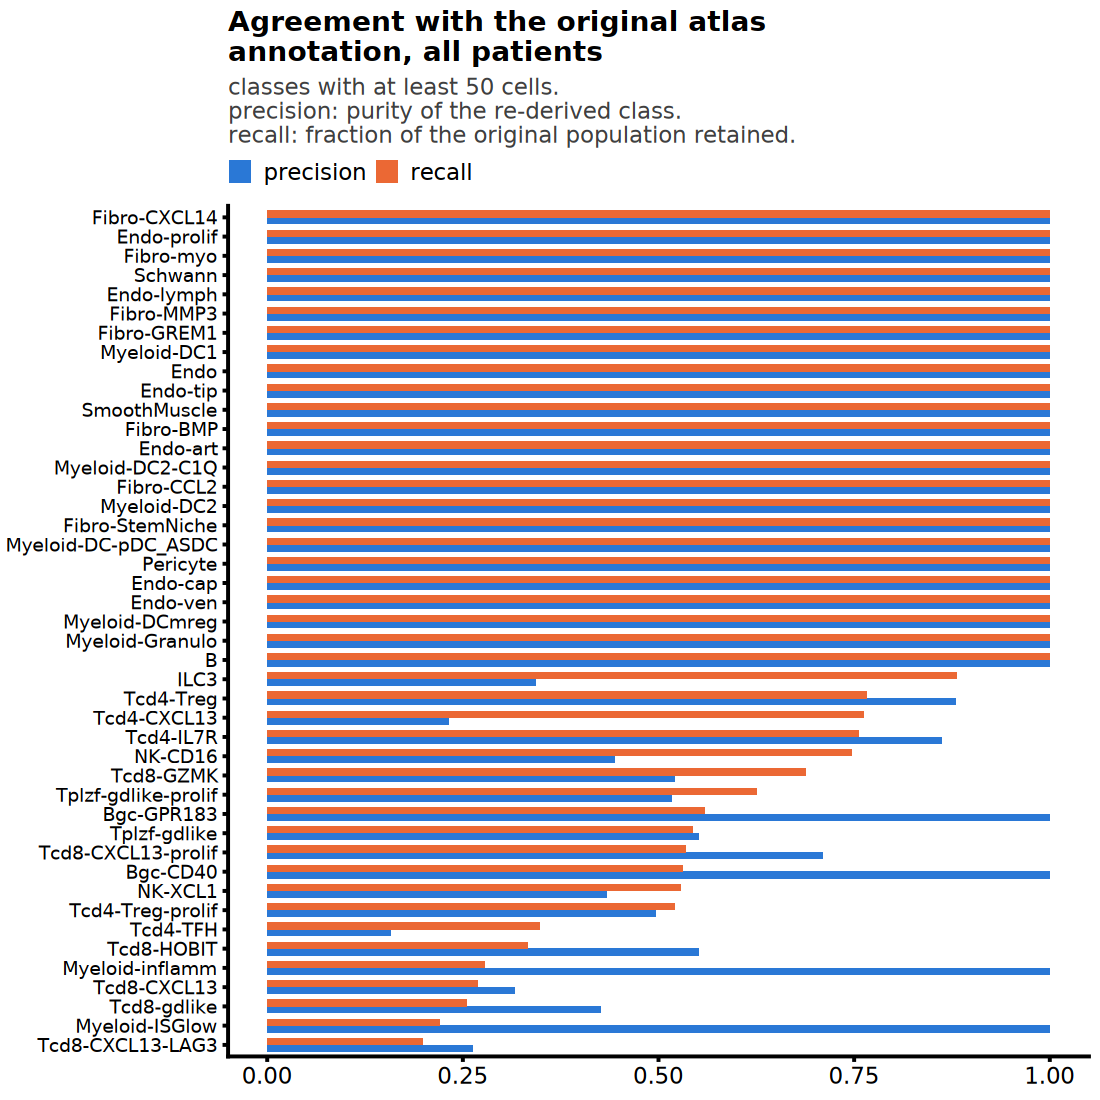

In [14]:
## precision and recall as a figure
pr_long <- melt(pr_all$res[!is.na(precision) & n_true >= 50],
                id.vars = c("class", "n_true"),
                measure.vars = c("precision", "recall"))
pr_long[, class := factor(class, levels = pr_all$res[order(recall), class])]

fig.size(height = 5.5, width = 5.5, res = 200)
p_pr <- ggplot(pr_long, aes(value, class, fill = variable)) +
    geom_col(position = position_dodge(width = 0.7), width = 0.65) +
    scale_fill_manual(values = c(precision = "#2a78d6", recall = "#eb6834")) +
    scale_x_continuous(limits = c(0, 1)) +
    labs(title = "Agreement with the original atlas\nannotation, all patients",
         subtitle = "classes with at least 50 cells.\nprecision: purity of the re-derived class.\nrecall: fraction of the original population retained.",
         x = NULL, y = NULL, fill = NULL) +
    theme_lt(7) +
    theme(legend.position = "top",
          legend.margin = margin(0, 0, 0, 0),
          axis.text.y = element_text(size = 6.5))
p_pr
ggsave(file.path(outdir_lt, "precision_recall.png"), p_pr,
       width = 5.5, height = 5.5, dpi = 300, bg = "white")

## 6. Compositional concordance between modalities

A second, weaker check: for the four patients profiled in both modalities, do the
cell type proportions agree? There is no cell-level correspondence between the
assays, so only proportions can be compared.

Two caveats belong in the response text. The MERFISH composition is restricted to
pathologist-annotated tumour regions, whereas the scRNA-seq was dissociated from
tissue that may include non-neoplastic mucosa. And dissociation depletes fragile
populations, so some disagreement is expected on tissue-handling grounds alone
and is not evidence about label transfer.

In [15]:
## MERFISH composition, using the same vocabulary as the Figure 4 reanalysis
tm <- readr::read_rds(file.path(TESSERA_DIR, "tile_metadata_2025-07-22.rds")); setDT(tm)
## CRITICAL: the scRNA references cover only a subset of lineages (there is no
## epithelial object, for instance). Comparing proportions computed over
## different denominators is meaningless and produces a negative correlation by
## construction. Restrict BOTH modalities to the lineages present in both, then
## renormalise within those lineages.
sc_lineages     <- sort(unique(scrna$lineage))
mf_lineages     <- sort(unique(as.character(tm$type_lvl1)))
shared_lineages <- intersect(FINE_TYPED_LINEAGES, intersect(sc_lineages, mf_lineages))

cat("scRNA lineages:  ", paste(sc_lineages, collapse = ", "), "\n")
cat("MERFISH lineages:", paste(mf_lineages, collapse = ", "), "\n")
cat("fine typed, used here:", paste(shared_lineages, collapse = ", "), "\n")
cat("excluded, not fine typed:",
    paste(setdiff(mf_lineages, shared_lineages), collapse = ", "), "\n\n")
if (!length(shared_lineages)) stop("no shared lineages; check type_lvl1 against clTopLevel")

mf_comp <- tm[PatientID %in% MATCHED_PATIENTS &
              as.character(type_lvl1) %in% shared_lineages,
              .(n = .N), by = .(patient = PatientID, label = as.character(type_lvl2))]
mf_comp[, pct_merfish := 100 * n / sum(n), by = patient]

sc_comp <- scrna[patient %in% MATCHED_PATIENTS & !is.na(new_label_lvl2) &
                 lineage %in% shared_lineages,
                 .(n = .N), by = .(patient, label = new_label)]
sc_comp[, pct_scrna := 100 * n / sum(n), by = patient]

cat("cells contributing, MERFISH:", mf_comp[, sum(n)],
    " scRNA:", sc_comp[, sum(n)], "\n")

comp <- merge(mf_comp[, .(patient, label, pct_merfish)],
              sc_comp[, .(patient, label, pct_scrna)],
              by = c("patient", "label"), all = TRUE)
comp[is.na(pct_merfish), pct_merfish := 0][is.na(pct_scrna), pct_scrna := 0]
comp <- comp[pct_merfish > 0 | pct_scrna > 0]
comp[, log2_ratio := log2((pct_merfish + 0.01) / (pct_scrna + 0.01))]
comp[, is_key := label %in% KEY_SUBSETS]

fwrite(comp, file.path(outdir_lt, "composition_concordance.csv"))
cc <- comp[, .(labels = .N,
               r_log = round(cor(log10(pct_merfish + 0.01),
                                 log10(pct_scrna + 0.01)), 3)), by = patient]
print(cc)
if (any(cc$r_log < 0)) {
    warning("negative correlation between modalities. This almost always means ",
            "the two compositions are computed over different denominators. ",
            "Check the shared-lineage restriction above before interpreting.")
}

scRNA lineages:   B, Myeloid, Strom, TNKILC 
MERFISH lineages: B, Epi, Myeloid, Plasma, Strom, TNKILC 
fine typed, used here: B, Myeloid, Strom, TNKILC 
excluded, not fine typed: Epi, Plasma 

cells contributing, MERFISH: 321864  scRNA: 10996 
Key: <patient>
   patient labels  r_log
    <char>  <int>  <num>
1:    C107     57 -0.305
2:    C110     57 -0.236
3:    C123     57 -0.248
4:    C164     57 -0.321


Warning message:
“negative correlation between modalities. This almost always means the two compositions are computed over different denominators. Check the shared-lineage restriction above before interpreting.”


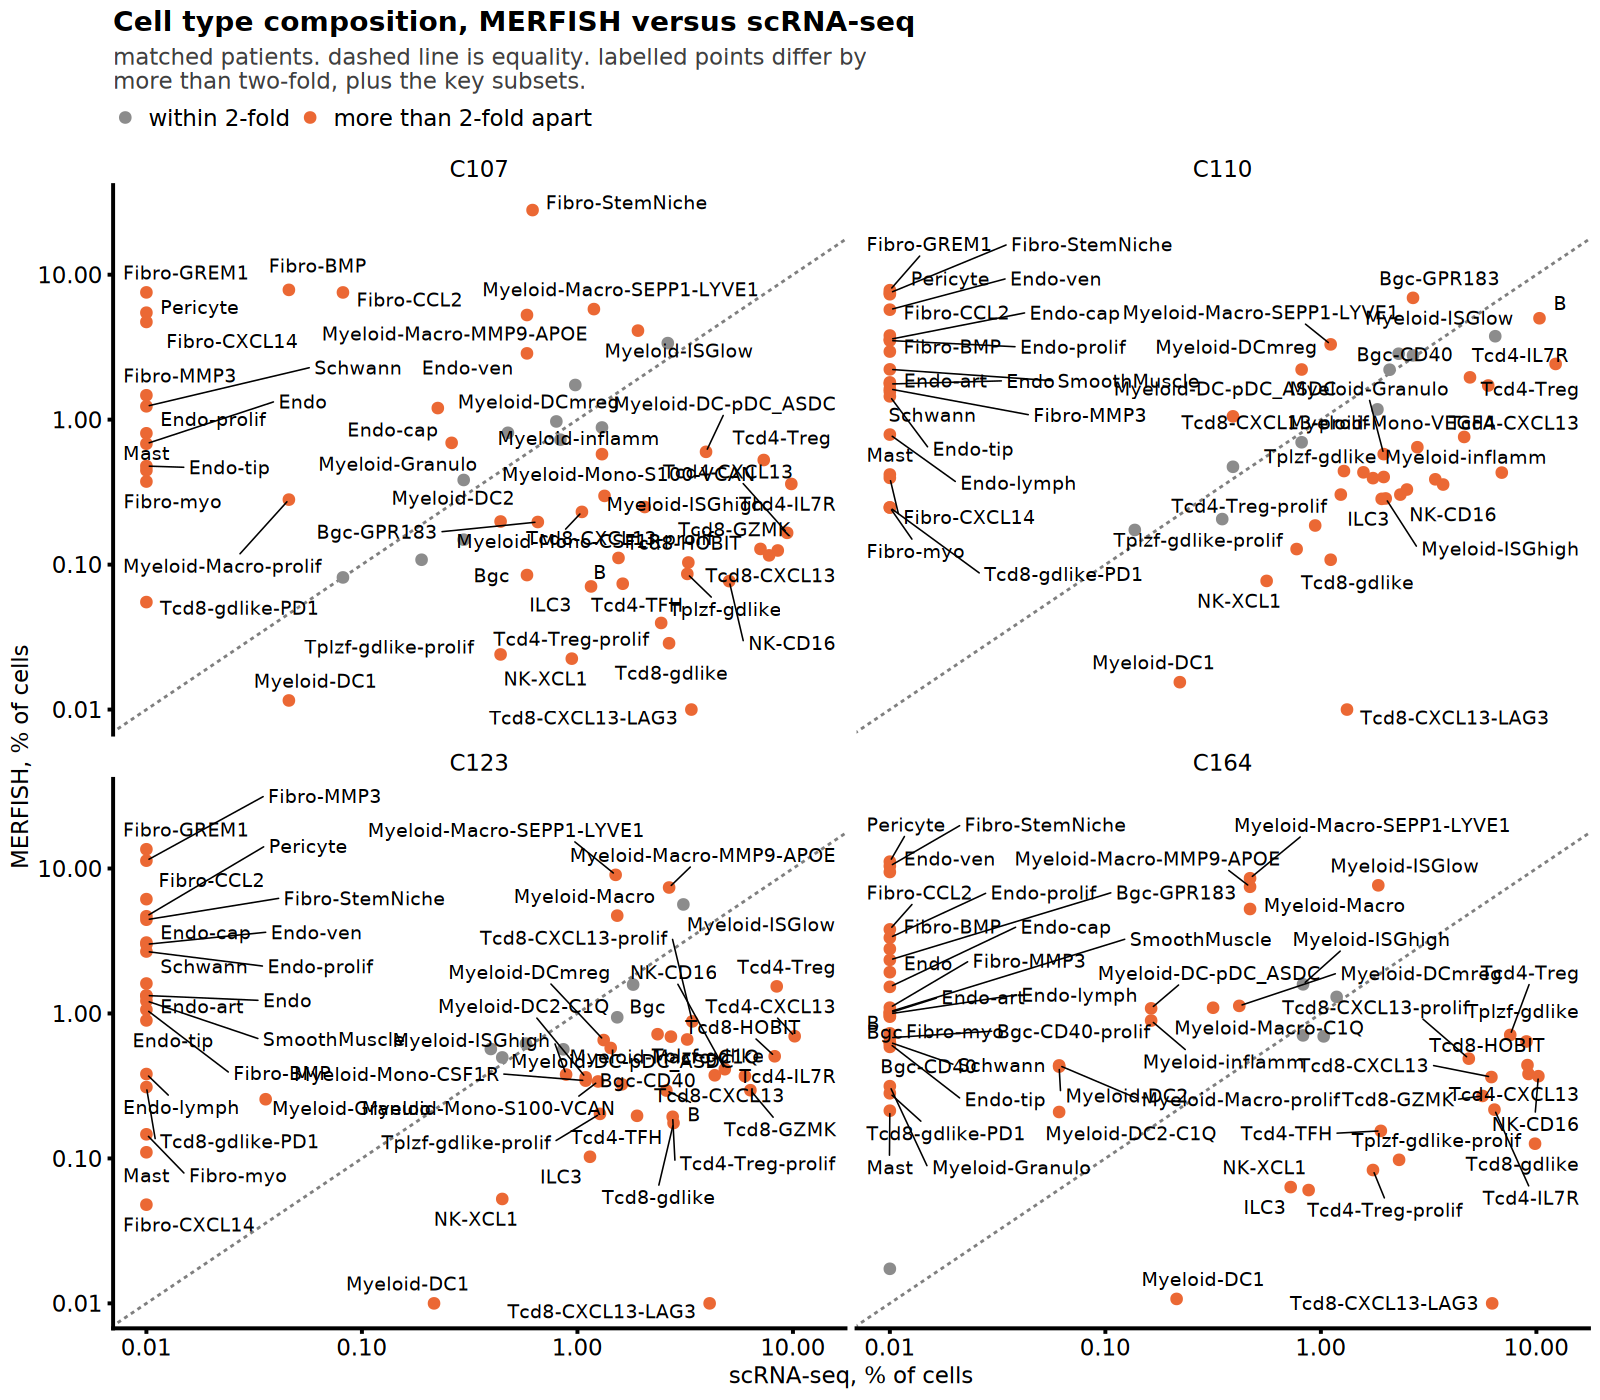

In [16]:
## primary view: log-log scatter with the identity line, off-diagonal labelled
fig.size(height = 7, width = 8, res = 200)
comp[, off_diag := abs(log2_ratio) > 1]

p_sc <- ggplot(comp, aes(pct_scrna + 0.01, pct_merfish + 0.01)) +
    geom_abline(slope = 1, intercept = 0, linetype = "dashed", colour = "grey50") +
    geom_point(aes(colour = off_diag), size = 1.4) +
    (if (HAS_REPEL)
        ggrepel::geom_text_repel(data = comp[off_diag == TRUE | is_key == TRUE],
                                 aes(label = label), size = 2.4, max.overlaps = 20,
                                 segment.size = 0.2)
     else geom_text(data = comp[off_diag == TRUE | is_key == TRUE],
                    aes(label = label), size = 2.4, hjust = -0.1, vjust = 0)) +
    scale_x_log10() + scale_y_log10() +
    scale_colour_manual(values = c(`FALSE` = "grey55", `TRUE` = "#eb6834"),
                        labels = c("within 2-fold", "more than 2-fold apart")) +
    facet_wrap(~ patient) +
    labs(title = "Cell type composition, MERFISH versus scRNA-seq",
         subtitle = wrap_title(paste("matched patients. dashed line is equality.",
                                     "labelled points differ by more than two-fold,",
                                     "plus the key subsets."), 70),
         x = "scRNA-seq, % of cells", y = "MERFISH, % of cells", colour = NULL) +
    theme_lt() + theme(legend.position = "top")
p_sc
ggsave(file.path(outdir_lt, "composition_scatter.png"), p_sc,
       width = 8, height = 7, dpi = 300, bg = "white")

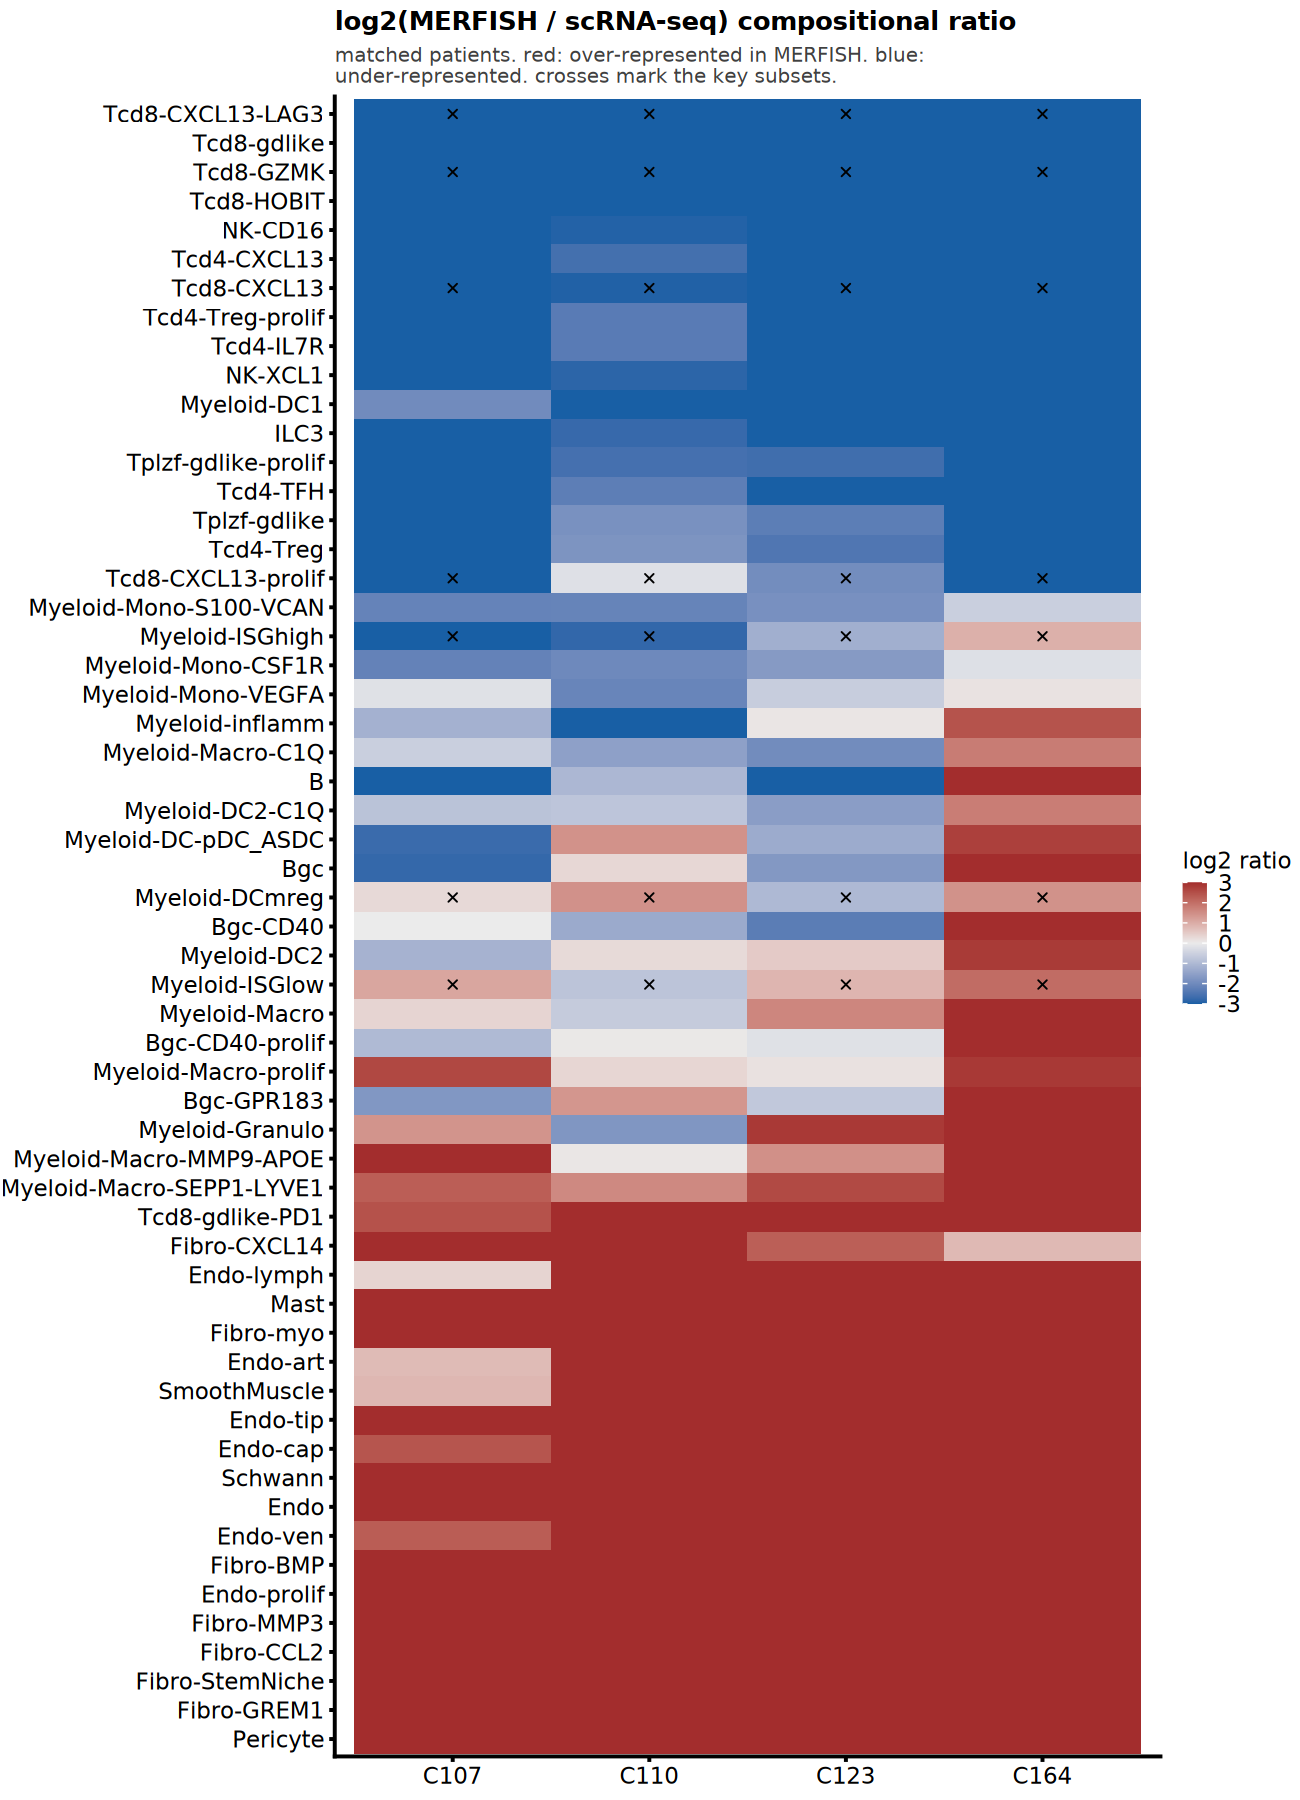

In [17]:
## backup view: log2 ratio heatmap, cell types by patient
ord <- comp[, .(m = mean(log2_ratio)), by = label][order(-m), label]
comp[, label_f := factor(label, levels = ord)]

fig.size(height = 9, width = 6.5, res = 200)
p_hm <- ggplot(comp, aes(patient, label_f, fill = log2_ratio)) +
    geom_tile() +
    geom_point(data = comp[is_key == TRUE], aes(x = patient), shape = 4,
               size = 1.2, colour = "black") +
    scale_fill_gradient2(low = "#185FA5", mid = "grey92", high = "#A32D2D",
                         midpoint = 0, limits = c(-3, 3), oob = scales::squish) +
    labs(title = "log2(MERFISH / scRNA-seq) compositional ratio",
         subtitle = wrap_title(paste("matched patients.",
                                     "red: over-represented in MERFISH.",
                                     "blue: under-represented.",
                                     "crosses mark the key subsets."), 58),
         x = NULL, y = NULL, fill = "log2 ratio") +
    theme_lt() +
    theme(plot.title = element_text(size = 9), plot.subtitle = element_text(size = 7))
p_hm
ggsave(file.path(outdir_lt, "composition_heatmap.png"), p_hm,
       width = 6.5, height = 9, dpi = 300, bg = "white")

## 7. Export

In [18]:
fwrite(scrna, file.path(outdir_lt, "scrna_labels_standardised.csv"))
saveRDS(list(cols = c(old = COL_OLD, lineage = COL_LINEAGE, new = COL_NEW,
                      patient = COL_PATIENT, cellid = COL_CELLID),
             manual_relabel = MANUAL_RELABEL,
             matched_patients = MATCHED_PATIENTS,
             key_subsets = KEY_SUBSETS,
             key_subset_map = KEY_SUBSET_MAP,
             full_name_map = FULL_NAME_MAP,
             name_map_table = name_map_tab,
             n_cells = nrow(scrna),
             created = Sys.time()),
        file.path(outdir_lt, "label_transfer_parameters.rds"))
cat("written to", outdir_lt, "\n")
sessionInfo()

written to ./label_transfer_fidelity_outputs 


R version 4.5.3 (2026-03-11)
Platform: x86_64-conda-linux-gnu
Running under: AlmaLinux 8.10 (Cerulean Leopard)

Matrix products: default
BLAS/LAPACK: /home/helikarlab/mukta/.conda/envs/r-analysis-env/lib/libopenblasp-r0.3.34.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: America/Chicago
tzcode source: system (glibc)

attached base packages:
[1] grid      stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] cowplot_1.2.0      Seurat_5.5.1       SeuratObject_5.4.0 sp_2.2-3          
 [5] readxl_1.5.0       patchwork_1.3.2    ggrastr_1.0.2      glmmTMB_1.1.14    
 [9] ggpubr_1.0.0       RC